In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [2]:
# Import the CSV Data as Pandas DataFrame
df = pd.read_csv('../data/cardekho_imputated.csv')
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [3]:
## Remove Unnecessary Columns
df.drop('car_name', axis=1, inplace=True)
df.drop('brand', axis=1, inplace=True)
df.drop('Unnamed: 0', axis=1, inplace=True)

In [3]:
df.drop(['car_name','brand','Unnamed: 0'], axis=1, inplace=True)

In [4]:
df.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [6]:
## Indpendent and dependent features
from sklearn.model_selection import train_test_split
X = df.drop(['selling_price'], axis=1)
y = df['selling_price']

In [7]:
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((12328, 10), (3083, 10))

In [8]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train[['model']] = oe.fit_transform(X_train[['model']])
X_test[['model']] = oe.transform(X_test[['model']])

In [9]:
X_train.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
11210,106.0,7,70252,Dealer,Diesel,Automatic,11.20,2400,215.0,5
1347,89.0,2,10000,Individual,Petrol,Manual,23.84,1199,84.0,5
10363,16.0,2,6000,Dealer,Diesel,Automatic,19.00,1950,241.3,5
316,24.0,7,63000,Dealer,Petrol,Manual,17.80,1497,117.3,5
10638,115.0,10,80292,Dealer,Petrol,Manual,20.36,1197,78.9,5


In [10]:
# Create Column Transformer with 3 types of transformers
num_features = X_train.select_dtypes(exclude="str").columns
onehot_columns = ['seller_type','fuel_type','transmission_type']

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, onehot_columns),
        ("StandardScaler", numeric_transformer, num_features)
        
    ],remainder='passthrough'
    
)

In [11]:
num_features

Index(['model', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power',
       'seats'],
      dtype='str')

In [10]:
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

In [12]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.260263,0.323969,0.349100,-2.050819,1.756765,2.681685,-0.403824
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.784851,-1.337798,-1.069394,0.985661,-0.547081,-0.382744,-0.403824
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.256624,-1.337798,-1.163564,-0.177042,0.893542,3.296910,-0.403824
3,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-1.032901,0.323969,0.178369,-0.465315,0.024564,0.396229,-0.403824
4,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.511951,1.321030,0.585469,0.149668,-0.550917,-0.502047,-0.403824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12323,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.557489,0.323969,1.702310,0.248161,-0.453086,-0.270460,2.070500
12324,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.896712,1.653383,0.084198,-0.876105,0.218310,0.066393,-0.403824
12325,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.036539,0.323969,-0.833967,0.185702,-0.932654,-0.779483,-0.403824
12326,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.539917,-1.337798,-0.951680,-0.273133,-0.550917,-0.432805,-0.403824


In [13]:
##Create a Function to Evaluate Model
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 553869.3883
- Mean Absolute Error: 268079.1643
- R2 Score: 0.6218
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 502411.7952
- Mean Absolute Error: 279571.6352
- R2 Score: 0.6647


Lasso
Model performance for Training set
- Root Mean Squared Error: 553869.3927
- Mean Absolute Error: 268076.7831
- R2 Score: 0.6218
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 502410.9457
- Mean Absolute Error: 279567.8124
- R2 Score: 0.6647


Ridge
Model performance for Training set
- Root Mean Squared Error: 553870.0372
- Mean Absolute Error: 268037.6463
- R2 Score: 0.6218
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 502402.7934
- Mean Absolute Error: 279510.5101
- R2 Score: 0.6647


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 321294.3295
- Mean 

In [15]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
7,CatBoosting Regressor,0.953585
5,Random Forest Regressor,0.931565
3,K-Neighbors Regressor,0.910658
4,Decision Tree,0.874854
6,XGBRegressor,0.825980
2,Ridge,0.664699
1,Lasso,0.664688
0,Linear Regression,0.664687
8,AdaBoost Regressor,0.538806


In [16]:
cat_model = CatBoostRegressor(verbose=False)
cat_model = cat_model.fit(X_train, y_train)
y_pred = cat_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 95.36


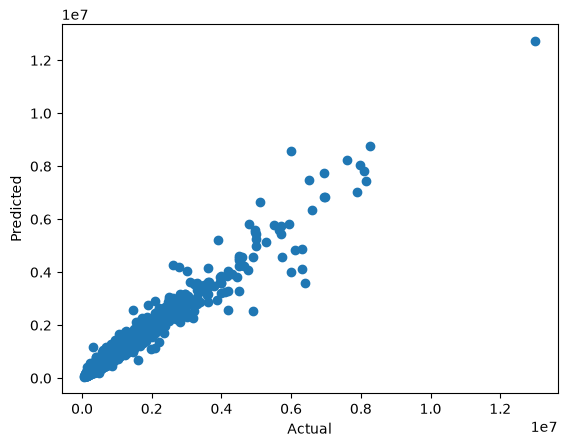

In [17]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

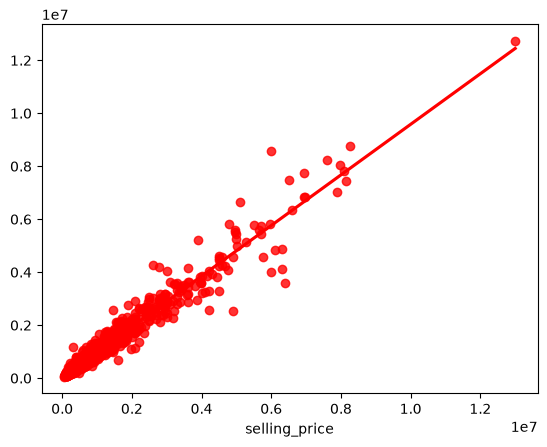

In [18]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');